In [1]:
import pandas as pd
import os

file_name = "processed_chocolate_sales.csv"
data_path = os.path.join("../datasets/processed/", file_name)

df = pd.read_csv(data_path)
df.head()

,Country,Product,Amount,Boxes_Shipped,Month,log_amount
0,UK,Mint Chip Choco,5320.0,180,1,8.579417
1,India,85% Dark Bars,7896.0,94,8,8.974238
2,India,Peanut Butter Cubes,4501.0,91,7,8.412277
3,Australia,Peanut Butter Cubes,12726.0,342,4,9.451481
4,UK,Peanut Butter Cubes,13685.0,184,2,9.524129


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

X = df.drop(columns=["log_amount", "Amount"])
y = df["log_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

categorical_features = ["Country", "Product"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

param_grid = {
    "model__n_estimators": [400, 800],
    "model__max_depth": [None, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, None],
    "model__bootstrap": [True],
    "model__max_samples": [0.7, 0.9, None],   
}

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)
print("Test R²:", best_model.score(X_test, y_test))

Best Params: {'model__bootstrap': True, 'model__max_depth': 40, 'model__max_features': 'sqrt', 'model__max_samples': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 800}
Best CV R²: 0.6934247086674254
Test R²: 0.7768620705980049


In [4]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = best_model.predict(X_test)

print("\n=== Test Metrics ===")
print("R²  :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


=== Test Metrics ===
R²  : 0.7768620705980049
MAE : 0.3165834805866622
RMSE: 0.4941777297835348


In [5]:
rf = best_model.named_steps["model"]

pre = best_model.named_steps["preprocess"]
feature_names = pre.get_feature_names_out()

importances = rf.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n=== Top 20 Important Features ===")
print(fi.head(20))


=== Top 20 Important Features ===
                              feature  importance
28                 num__Boxes_Shipped    0.416647
29                         num__Month    0.183731
2                  cat__Country_India    0.024871
3            cat__Country_New Zealand    0.024860
0              cat__Country_Australia    0.023033
1                 cat__Country_Canada    0.022659
5                    cat__Country_USA    0.022089
4                     cat__Country_UK    0.020517
23   cat__Product_Peanut Butter Cubes    0.016861
9        cat__Product_99% Dark & Pure    0.016005
25    cat__Product_Smooth Sliky Salty    0.015775
26   cat__Product_Spicy Special Slims    0.014213
6         cat__Product_50% Dark Bites    0.013916
22   cat__Product_Organic Choco Syrup    0.013251
17      cat__Product_Fruit & Nut Bars    0.012970
10           cat__Product_After Nines    0.012835
7         cat__Product_70% Dark Bites    0.012591
15         cat__Product_Drinking Coco    0.012362
16             

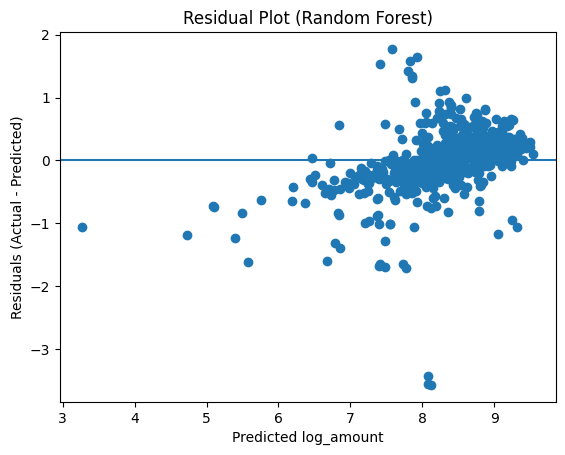

In [7]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted log_amount")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Random Forest)")
plt.show()

In [8]:
import os
import json
import joblib

os.makedirs("../../models", exist_ok=True)

model_path = "../../models/random_forest_sales_model.pkl"
joblib.dump(best_model, model_path)

categorical_values = {
    col: sorted(X[col].dropna().unique().tolist())
    for col in categorical_features
}

feature_info = {
    "all_features": list(X.columns),
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "categorical_values": categorical_values
}

with open("../../models/feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print("Model and feature info saved successfully.")

Model and feature info saved successfully.
